# Generate Large-Scale Synthetic Datasets for Performance Benchmarking

> Author: Tianyu Du
>
> Updated: Mar. 16, 2025

The notebook generates synthetic choice datasets by: (1) subsampling 500 users and 30 items from a seed supermarket dataset containing latent user/item feature vectors (10-dimensional after dimensionality reduction), (2) selecting 100,000 purchase records that match these subsampled entities, (3) encoding user/item IDs with label encoders, (4) creating a PyTorch ChoiceDataset with latent features and purchase indices, and (5) generating an expanded CSV format with one-hot encoded choices and merged latent features for compatibility with traditional choice modeling tools.

In [1]:
import os
import sys
from time import ctime, time
from typing import Optional

import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import torch
import torch_choice
from torch_choice.data import ChoiceDataset
from tqdm import tqdm

import os
import numpy as np
import pandas as pd
import torch
from sklearn.preprocessing import LabelEncoder
from torch_choice.data import ChoiceDataset
from tqdm import tqdm
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt
from typing import Dict, List, Optional, Tuple, Union

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.manifold import TSNE
from torch_choice.data import ChoiceDataset

In [2]:
# print system information, including python version, torch version, GPU information if available.
print(f"Python version: {sys.version}")
print(f"Torch version: {torch.__version__}")
if torch.cuda.is_available():
    print(f"GPU information: {torch.cuda.get_device_name(0)}")
else:
    print("No GPU available")

Python version: 3.9.7 | packaged by conda-forge | (default, Sep 29 2021, 19:24:02) 
[Clang 11.1.0 ]
Torch version: 2.6.0
No GPU available


## Configuration of the Synthetic Dataset Generation.

In [3]:
OUTPUT_PATH = "./synthetic_data"
os.makedirs(OUTPUT_PATH, exist_ok=True)
print(f"Synthetic dataset will be saved to: {OUTPUT_PATH}")

Synthetic dataset will be saved to: /Users/tianyudu/Downloads/torch_choice_data_compare/generated


# Generate Synthetic Datasets for Performance Benchmarking

In [4]:
def generate_clustered_latents(
    num_entities: int,
    latent_dim: int,
    num_clusters: int,
    cluster_std: float = 0.5,
    between_cluster_distance: float = 3.0,
    random_state: int = 42
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Generate latent vectors organized in clusters.

    Args:
        num_entities: Number of entities (users or items) to generate
        latent_dim: Dimension of the latent space
        num_clusters: Number of clusters to create
        cluster_std: Standard deviation within each cluster
        between_cluster_distance: Controls separation between cluster centers
        random_state: Random seed for reproducibility

    Returns:
        latents: Array of shape (num_entities, latent_dim) with latent vectors
        cluster_assignments: Array of cluster assignments for each entity
    """
    np.random.seed(random_state)

    # Generate cluster centers that are well separated
    cluster_centers = np.random.randn(num_clusters, latent_dim) * between_cluster_distance

    # Determine how many entities belong to each cluster
    entities_per_cluster = np.full(num_clusters, num_entities // num_clusters)
    # Add remaining entities to random clusters
    remainder = num_entities % num_clusters
    if remainder > 0:
        extra_indices = np.random.choice(num_clusters, remainder, replace=False)
        entities_per_cluster[extra_indices] += 1

    latents = []
    cluster_assignments = []

    # Generate entities for each cluster
    for cluster_idx in range(num_clusters):
        # Generate points around the cluster center
        cluster_latents = np.random.normal(
            loc=cluster_centers[cluster_idx],
            scale=cluster_std,
            size=(entities_per_cluster[cluster_idx], latent_dim)
        )
        latents.append(cluster_latents)
        cluster_assignments.extend([cluster_idx] * entities_per_cluster[cluster_idx])

    # Concatenate all latents
    latents = np.vstack(latents)
    print(f"Created latent with {latents.shape[0]} entities and {latents.shape[1]} dimensions; the array has shape {latents.shape}.")
    cluster_assignments = np.array(cluster_assignments)

    return latents, cluster_assignments

In [5]:
def generate_price_coefficients(
    num_users: int,
    mean: float = -1.5,
    std: float = 0.5,
    random_state: int = 42
) -> np.ndarray:
    """
    Generate price coefficients for users.

    Args:
        num_users: Number of users
        mean: Mean of the price coefficient distribution (typically negative)
        std: Standard deviation of price coefficients
        random_state: Random seed

    Returns:
        price_coefficients: Array of shape (num_users,) with price coefficients
    """
    np.random.seed(random_state)
    return np.random.normal(loc=mean, scale=std, size=num_users)

In [6]:
def generate_prices_and_availability(
    num_items: int,
    num_sessions: int,
    price_mean: float = 10.0,
    price_std: float = 3.0,
    availability_prob: float = 0.9,
    random_state: int = 42
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Generate prices and availability for items across sessions.

    Args:
        num_items: Number of items
        num_sessions: Number of sessions
        price_mean: Mean price
        price_std: Standard deviation of prices
        availability_prob: Probability that an item is available
        random_state: Random seed

    Returns:
        prices: Array of shape (num_sessions, num_items) with prices
        availability: Boolean array of shape (num_sessions, num_items)
    """
    np.random.seed(random_state)

    # Generate prices with some temporal correlation
    base_prices = np.random.normal(loc=price_mean, scale=price_std, size=num_items)
    # Ensure all prices are positive
    base_prices = np.maximum(base_prices, 1.0)

    # Create session-specific price variations
    prices = np.zeros((num_sessions, num_items))
    for i in range(num_items):
        # Add small random variations to create price fluctuations
        variations = np.random.normal(0, price_std * 0.2, num_sessions)
        prices[:, i] = base_prices[i] + variations

    # Ensure all prices are positive
    prices = np.maximum(prices, 1.0)

    # Generate availability (some items might be out of stock in some sessions)
    availability = np.random.binomial(1, availability_prob, size=(num_sessions, num_items)).astype(bool)

    # Ensure each session has at least one available item
    for s in range(num_sessions):
        if not np.any(availability[s]):
            availability[s, np.random.randint(0, num_items)] = True

    return prices, availability

In [7]:
def simulate_choice_behavior(
    user_latents: np.ndarray,
    item_latents: np.ndarray,
    prices: np.ndarray,
    availability: np.ndarray,
    price_coefficients: np.ndarray,
    num_records: int,
    choice_noise: float = 0.7,       # Increased noise
    exploration_prob: float = 0.15,  # Probability of random exploration
    temperature: float = 2.0,        # Temperature for softmax selection
    random_state: int = 42
):
    """
    Simulate users making choices based on utility with added noise and exploration.
    Always selects an item (no outside option).

    Args:
        user_latents: User latent vectors
        item_latents: Item latent vectors
        prices: Prices for each item in each session
        availability: Boolean availability for each item in each session
        price_coefficients: Price sensitivity coefficients for each user
        num_records: Number of records to generate
        choice_noise: Noise level for utility calculation
        exploration_prob: Probability of random exploration (ignoring utility)
        temperature: Temperature parameter for softmax selection
        random_state: Random seed

    Returns:
        user_indices, session_indices, item_indices for the generated choices
    """
    np.random.seed(random_state)

    num_users, latent_dim = user_latents.shape
    num_items = item_latents.shape[0]
    num_sessions = prices.shape[0]

    # Randomly select users and sessions for each record
    user_indices = np.random.randint(0, num_users, size=num_records)
    session_indices = np.random.randint(0, num_sessions, size=num_records)
    item_indices = np.zeros(num_records, dtype=int)

    # Pre-compute dot product for efficiency with progress bar
    print("Pre-computing user-item compatibility matrix...")

    # Pre-compute in batches with progress tracking for large matrices
    batch_size = 100  # Process users in batches
    ui_compatibility = np.zeros((num_users, num_items))

    for i in tqdm(range(0, num_users, batch_size), desc="Computing compatibility"):
        end_idx = min(i + batch_size, num_users)
        ui_compatibility[i:end_idx] = user_latents[i:end_idx] @ item_latents.T

    # For each record, compute utility and make a choice, with progress bar
    print("Simulating choice behaviors with added exploration...")
    for i in tqdm(range(num_records), desc="Simulating choices"):
        user_idx = user_indices[i]
        session_idx = session_indices[i]

        # Find available items in this session
        available_mask = availability[session_idx]

        # Ensure at least one item is available
        if not np.any(available_mask):
            # Make a random item available if none are
            random_item = np.random.randint(0, num_items)
            available_mask[random_item] = True

        available_items = np.where(available_mask)[0]

        # Decision: explore randomly or exploit based on utility?
        if np.random.random() < exploration_prob:
            # Random exploration: choose randomly from available items
            item_indices[i] = np.random.choice(available_items)
            continue

        # Regular utility-based choice
        # Base utility from latent factors (pre-computed)
        base_utility = ui_compatibility[user_idx]

        # Price effect
        price_effect = price_coefficients[user_idx] * prices[session_idx]

        # Total utility
        utility = base_utility + price_effect

        # Add choice noise
        utility += np.random.normal(0, choice_noise, size=utility.shape)

        # Set utility of unavailable items to negative infinity
        masked_utility = utility.copy()
        masked_utility[~available_mask] = float('-inf')

        # Choose using softmax with temperature sometimes, and argmax otherwise
        if np.random.random() < 0.35:  # 35% of time use softmax
            # Apply softmax with temperature to get probabilities
            max_utility = np.max(masked_utility)
            exp_utility = np.exp((masked_utility - max_utility) / temperature)
            exp_utility[~available_mask] = 0  # Ensure unavailable items have 0 probability
            probs = exp_utility / np.sum(exp_utility)
            item_indices[i] = np.random.choice(num_items, p=probs)
        else:
            # Use standard argmax
            item_indices[i] = np.argmax(masked_utility)

    return user_indices, session_indices, item_indices

In [8]:
# Parameters as specified
num_users = 500
num_items = 500
latent_dim = 30
num_user_clusters = 5
num_item_clusters = 5

print("Generating user and item latent vectors...")
user_latents, user_cluster_assignments = generate_clustered_latents(
    num_entities=num_users,
    latent_dim=latent_dim,
    num_clusters=num_user_clusters,
    cluster_std=0.5,
    between_cluster_distance=3.0,
    random_state=42
)

item_latents, item_cluster_assignments = generate_clustered_latents(
    num_entities=num_items,
    latent_dim=latent_dim,
    num_clusters=num_item_clusters,
    cluster_std=0.3,
    between_cluster_distance=2.5,
    random_state=43
)

print(f"User latents shape: {user_latents.shape}")
print(f"Item latents shape: {item_latents.shape}")
print(f"User cluster distribution: {np.bincount(user_cluster_assignments)}")
print(f"Item cluster distribution: {np.bincount(item_cluster_assignments)}")

Generating user and item latent vectors...
Created latent with 500 entities and 30 dimensions; the array has shape (500, 30).
Created latent with 500 entities and 30 dimensions; the array has shape (500, 30).
User latents shape: (500, 30)
Item latents shape: (500, 30)
User cluster distribution: [100 100 100 100 100]
Item cluster distribution: [100 100 100 100 100]


Applying t-SNE to reduce dimensionality for visualization...
Processing user latents with t-SNE...
Processing item latents with t-SNE...


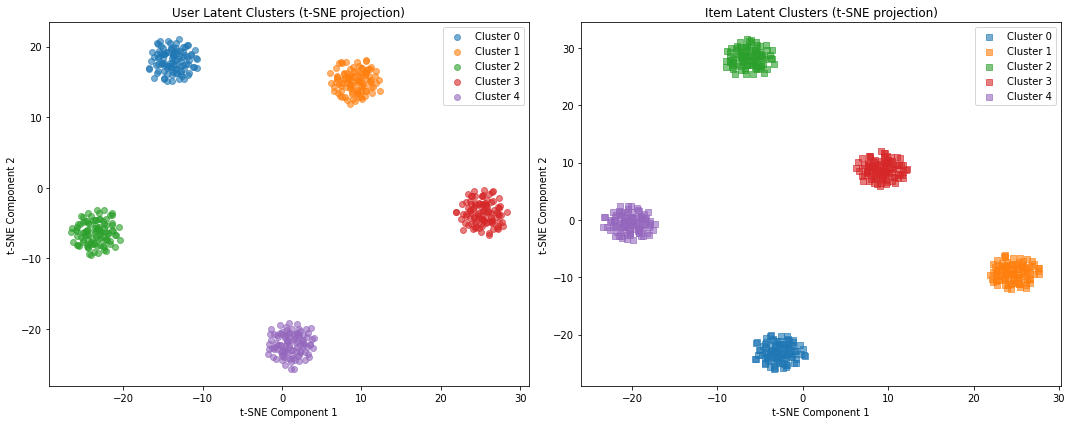

In [9]:
# Apply t-SNE to reduce dimensionality for visualization
print("Applying t-SNE to reduce dimensionality for visualization...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)

# Apply t-SNE to user latents
print("Processing user latents with t-SNE...")
user_latents_2d = tsne.fit_transform(user_latents)

# Reset the random state for consistent but different user and item visualizations
tsne = TSNE(n_components=2, random_state=43, perplexity=30, n_iter=1000)

# Apply t-SNE to item latents
print("Processing item latents with t-SNE...")
item_latents_2d = tsne.fit_transform(item_latents)

# Create t-SNE visualizations
plt.figure(figsize=(15, 6))

# Plot user clusters in t-SNE space
plt.subplot(1, 2, 1)
for cluster_id in range(num_user_clusters):
    mask = user_cluster_assignments == cluster_id
    plt.scatter(
        user_latents_2d[mask, 0],
        user_latents_2d[mask, 1],
        label=f"Cluster {cluster_id}",
        alpha=0.6
    )
plt.title("User Latent Clusters (t-SNE projection)")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.legend()

# Plot item clusters in t-SNE space
plt.subplot(1, 2, 2)
for cluster_id in range(num_item_clusters):
    mask = item_cluster_assignments == cluster_id
    plt.scatter(
        item_latents_2d[mask, 0],
        item_latents_2d[mask, 1],
        label=f"Cluster {cluster_id}",
        alpha=0.6,
        marker='s'
    )
plt.title("Item Latent Clusters (t-SNE projection)")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.legend()

plt.tight_layout()
plt.show()

In [10]:
# Generate price coefficients and session data
num_sessions = 1000
print("Generating price coefficients and session data...")
price_coefficients = generate_price_coefficients(
    num_users=num_users,
    mean=-1.5,
    std=0.5,
    random_state=44
)

prices, availability = generate_prices_and_availability(
    num_items=num_items,
    num_sessions=num_sessions,
    price_mean=10.0,
    price_std=3.0,
    availability_prob=0.95,  # 95% items available in each session
    random_state=45
)

print(f"Price coefficients range: [{price_coefficients.min():.2f}, {price_coefficients.max():.2f}]")
print(f"Prices shape: {prices.shape}")
print(f"Prices range: [{prices.min():.2f}, {prices.max():.2f}]")
print(f"Average item availability: {availability.mean()*100:.1f}%")

Generating price coefficients and session data...
Price coefficients range: [-3.04, -0.05]
Prices shape: (1000, 500)
Prices range: [1.00, 21.06]
Average item availability: 94.9%


In [11]:
# Simulate choices
num_records = 3_000_000
print("Simulating choice behaviors...")
user_indices, session_indices, item_indices = simulate_choice_behavior(
    user_latents=user_latents,
    item_latents=item_latents,
    prices=prices,
    availability=availability,
    price_coefficients=price_coefficients,
    num_records=num_records,
    choice_noise=0.5,
    exploration_prob=0.5,
    random_state=42
)

print(f"Generated {len(user_indices)} choice records (after filtering outside option)")

Simulating choice behaviors...
Pre-computing user-item compatibility matrix...


Computing compatibility: 100%|██████████| 5/5 [00:00<00:00, 161.23it/s]


Simulating choice behaviors with added exploration...


Simulating choices: 100%|██████████| 3000000/3000000 [00:51<00:00, 58701.93it/s]

Generated 3000000 choice records (after filtering outside option)


Analyzing choice patterns...


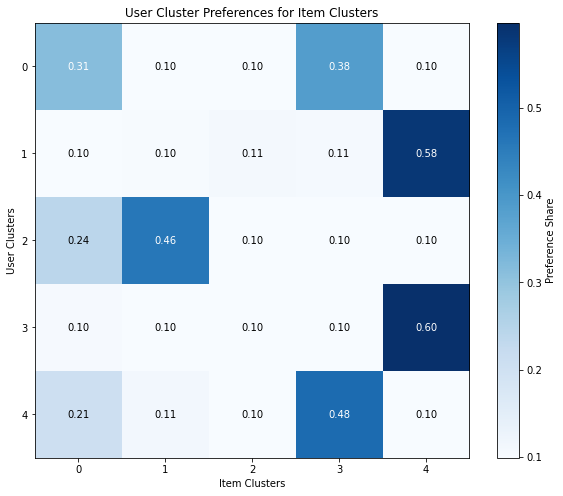

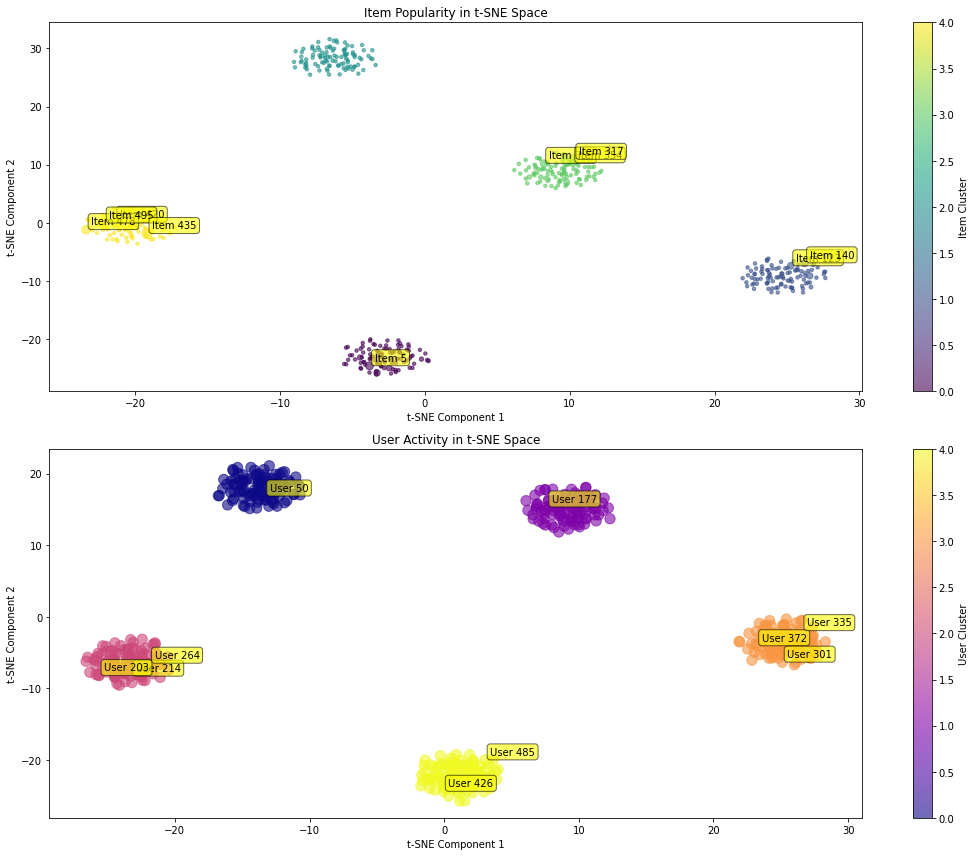

In [12]:
# Create a DataFrame for analysis
choices_df = pd.DataFrame({
    'user_id': user_indices,
    'user_cluster': user_cluster_assignments[user_indices],
    'item_id': item_indices,
    'item_cluster': item_cluster_assignments[item_indices],
    'session_id': session_indices
})

# Calculate preference matrix (user clusters vs item clusters)
print("Analyzing choice patterns...")
pref_matrix = np.zeros((num_user_clusters, num_item_clusters))
for u_cluster in range(num_user_clusters):
    for i_cluster in range(num_item_clusters):
        count = ((choices_df['user_cluster'] == u_cluster) &
                (choices_df['item_cluster'] == i_cluster)).sum()
        pref_matrix[u_cluster, i_cluster] = count

# Normalize by row (user cluster) to get relative preferences
pref_matrix_norm = pref_matrix / pref_matrix.sum(axis=1, keepdims=True)

# Visualize the preference matrix
plt.figure(figsize=(10, 8))
plt.imshow(pref_matrix_norm, cmap='Blues')
plt.colorbar(label='Preference Share')
plt.xlabel('Item Clusters')
plt.ylabel('User Clusters')
plt.title('User Cluster Preferences for Item Clusters')

# Add text annotations
for i in range(num_user_clusters):
    for j in range(num_item_clusters):
        plt.text(j, i, f'{pref_matrix_norm[i, j]:.2f}',
                ha='center', va='center',
                color='black' if pref_matrix_norm[i, j] < 0.3 else 'white')

plt.xticks(range(num_item_clusters))
plt.yticks(range(num_user_clusters))
plt.show()

# Create a visualization that shows item choices in the t-SNE space
plt.figure(figsize=(15, 12))

# Calculate item popularity
item_popularity = np.bincount(item_indices, minlength=num_items)
item_popularity_normalized = item_popularity / item_popularity.max()  # normalize for visualization

# Plot items in t-SNE space with size representing popularity
plt.subplot(2, 1, 1)
scatter = plt.scatter(
    item_latents_2d[:, 0],
    item_latents_2d[:, 1],
    c=item_cluster_assignments,
    s=item_popularity_normalized * 100 + 10,  # scale sizes for visibility
    alpha=0.6,
    cmap='viridis'
)

plt.colorbar(scatter, label='Item Cluster')
plt.title('Item Popularity in t-SNE Space')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')

# Add annotations for the top 10 most popular items
top_items = np.argsort(item_popularity)[-10:]
for item_id in top_items:
    plt.annotate(
        f"Item {item_id}",
        (item_latents_2d[item_id, 0], item_latents_2d[item_id, 1]),
        xytext=(5, 5),
        textcoords='offset points',
        bbox=dict(boxstyle="round", fc="yellow", alpha=0.6)
    )

# Plot users in t-SNE space
plt.subplot(2, 1, 2)
# Calculate user activity
user_activity = np.bincount(user_indices, minlength=num_users)
user_activity_normalized = user_activity / user_activity.max()  # normalize for visualization

scatter = plt.scatter(
    user_latents_2d[:, 0],
    user_latents_2d[:, 1],
    c=user_cluster_assignments,
    s=user_activity_normalized * 100 + 10,  # scale sizes for visibility
    alpha=0.6,
    cmap='plasma'
)

plt.colorbar(scatter, label='User Cluster')
plt.title('User Activity in t-SNE Space')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')

# Add annotations for the top 10 most active users
top_users = np.argsort(user_activity)[-10:]
for user_id in top_users:
    plt.annotate(
        f"User {user_id}",
        (user_latents_2d[user_id, 0], user_latents_2d[user_id, 1]),
        xytext=(5, 5),
        textcoords='offset points',
        bbox=dict(boxstyle="round", fc="yellow", alpha=0.6)
    )

plt.tight_layout()
plt.show()

In [13]:
# create user latents and item latents dataframes.
user_latents = pd.DataFrame(user_latents, columns=[f"user_latent_{i}" for i in range(latent_dim)])
user_latents["user_id"] = np.arange(num_users)
item_latents = pd.DataFrame(item_latents, columns=[f"item_latent_{i}" for i in range(latent_dim)])
item_latents["item_id"] = np.arange(num_items)

In [14]:
display(user_latents)
display(item_latents)

,user_latent_0,user_latent_1,user_latent_2,user_latent_3,user_latent_4,user_latent_5,user_latent_6,user_latent_7,user_latent_8,user_latent_9,...,user_latent_21,user_latent_22,user_latent_23,user_latent_24,user_latent_25,user_latent_26,user_latent_27,user_latent_28,user_latent_29,user_id
0,1.615389,-0.241569,1.603053,4.685216,-0.555924,-1.059587,5.670526,2.539221,-2.004075,1.955957,...,-1.085234,0.164034,-4.103669,-1.494803,0.746359,-3.446480,1.853861,-1.934244,0.485003,0
1,1.802976,-0.843372,1.407619,4.810326,-0.814192,-0.345411,4.974257,2.265890,-1.831820,0.870257,...,-0.396937,0.744110,-3.747344,-2.321983,-0.136145,-3.195463,1.383987,-1.544392,1.051284,1
2,1.775588,0.152990,2.420066,4.894785,-0.860095,-0.322926,4.351226,2.183895,-1.651105,1.668617,...,-0.569100,0.225371,-4.600045,-0.561176,0.649727,-4.465552,1.220321,-2.132809,-0.448865,2
3,1.093882,-0.472161,2.195559,5.001967,-1.302608,-0.869661,4.500166,1.975640,-0.525696,1.830171,...,-0.707092,-1.418049,-4.786438,-1.759432,-0.291124,-2.636775,0.412023,-2.021938,-0.809711,3
4,2.210779,-1.132724,2.524647,4.574206,-1.193214,-0.471359,4.837168,2.002196,-1.373522,1.435023,...,-0.923829,-0.092098,-3.849444,-1.454640,-0.013687,-3.003181,1.280744,-1.395485,-0.560267,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,2.301384,-2.744490,4.240530,-3.732122,1.386963,6.148193,-2.353299,-1.930216,-0.332564,-1.752992,...,3.988720,-4.166709,-0.016806,1.029768,1.721317,-3.663764,-3.591203,1.458573,1.166517,495
496,1.893230,-3.560007,4.486898,-3.333548,1.262549,7.182464,-2.949897,-2.366739,-0.266799,-1.502535,...,4.385464,-5.302375,0.441442,0.679104,1.726992,-3.920789,-4.998850,2.521914,0.422247,496
497,3.166153,-2.709120,4.490815,-4.449953,1.864536,6.896612,-2.639333,-1.311506,0.114788,-1.750607,...,3.886701,-4.804548,0.622975,-0.428033,2.352797,-4.825640,-3.595261,1.288262,-0.187564,497
498,1.965994,-3.013200,4.803733,-4.107234,1.932794,7.161978,-3.019681,-1.321799,0.640885,-2.153662,...,4.017524,-4.982534,0.283759,0.313174,2.031591,-3.886189,-4.205189,1.236737,1.940375,498


,item_latent_0,item_latent_1,item_latent_2,item_latent_3,item_latent_4,item_latent_5,item_latent_6,item_latent_7,item_latent_8,item_latent_9,...,item_latent_21,item_latent_22,item_latent_23,item_latent_24,item_latent_25,item_latent_26,item_latent_27,item_latent_28,item_latent_29,item_id
0,1.394959,-2.671242,-1.254740,-0.928338,1.802501,-1.444133,1.880083,4.943216,3.082110,-1.250686,...,-0.389160,5.945651,-1.101713,0.235676,2.561663,-0.087919,1.189610,0.527434,2.243462,0
1,0.683891,-1.992207,-0.928891,-1.451164,2.461369,-0.733631,0.612713,4.569763,3.196104,-1.117609,...,-0.286631,5.365741,-1.446936,0.106728,1.985560,-0.397053,1.492713,1.057772,2.151183,1
2,1.061179,-2.148817,-0.132214,-1.288889,2.023115,-1.481653,0.851160,5.297543,3.351834,-1.124947,...,0.105969,5.791327,-0.807164,0.082431,2.187878,-0.004242,1.779705,1.407319,2.079096,2
3,0.660510,-2.171880,-1.024792,-1.550068,2.195121,-0.890528,1.402583,5.002837,2.959742,-0.948257,...,-0.155096,5.008363,-1.012090,0.242670,2.394035,-0.125276,1.023158,0.863519,1.869653,3
4,0.291871,-2.799287,-0.802684,-0.983412,1.973759,-0.802551,1.406456,4.754238,3.122809,-1.085571,...,-0.707918,5.742541,-1.312308,0.297775,2.414098,-0.721058,1.247299,1.260049,2.140361,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,-0.765715,2.111171,-4.737893,-0.538988,-1.231996,-0.887520,4.154542,-1.252172,3.979686,2.956161,...,0.519428,-1.277865,3.425201,3.188620,0.594338,-0.040067,0.111613,0.213751,3.215682,495
496,-1.690180,1.499763,-4.872355,-0.326823,-1.582123,-0.130243,4.155019,-1.257586,3.715788,3.362686,...,1.087586,-1.322652,2.725558,3.559720,0.806963,0.090373,-0.319680,0.117969,2.312472,496
497,-0.850102,2.010054,-5.389379,-1.217311,-1.431634,0.067933,4.371682,-1.161309,3.800942,2.856540,...,0.671829,-1.538851,2.568624,2.928986,0.151686,0.094718,-0.062526,-0.129012,3.063554,497
498,-0.804545,2.032615,-5.613248,-0.711376,-1.940354,0.122722,4.860368,-1.145659,4.135547,3.031149,...,1.248449,-1.546268,2.302376,2.874163,0.026492,0.031408,0.210678,-0.440387,3.078769,498


## Load the Purchase Records $(u^{(n)}, i^{(n)}, s^{(n)})$ from the Seed Dataset

In [15]:
train_all = pd.DataFrame(data={"user_id": user_indices, "item_id": item_indices})
display(train_all)

print(f"Total number of purchase records: {len(train_all):,}")
print(f"Number of unique users: {train_all['user_id'].nunique():,} each appeared for {train_all.value_counts('user_id').mean():.2f} sessions on average.")
print(f"Number of unique items: {train_all['item_id'].nunique():,} each appeared for {train_all.value_counts('item_id').mean():.2f} times on average.")

,user_id,item_id
0,102,130
1,435,98
2,348,452
3,270,140
4,106,191
...,...,...
2999995,245,123
2999996,157,435
2999997,489,287
2999998,191,478


Total number of purchase records: 3,000,000
Number of unique users: 500 each appeared for 6000.00 sessions on average.
Number of unique items: 500 each appeared for 6000.00 times on average.


<!-- ## Subsample Data for Benchmarking -->

In [16]:
def simulate_choice_data(
    user_latents: pd.DataFrame,
    item_latents: pd.DataFrame,
    num_subsampled_items: int,
    num_subsampled_users: int,
    num_subsampled_latents: Optional[int]=None,
    num_subsampled_records: Optional[int]=None,
    seed: int=42,
    experiment_tag: Optional[str]=None,
    export_csv: bool=False,
) -> None:
    """
    Simulate choice data for performance benchmarking.

    This function samples a subset of users, items, and purchase records from global datasets,
    encodes latent features, and saves the resulting dataset in both torch and CSV formats.
    """
    # Set a default experiment tag if none is provided.
    if experiment_tag is None:
        experiment_tag = "default"

    np.random.seed(seed)  # Fix random seed for reproducibility

    # Check for completeness of the input data.
    missing_user_latents = [f"user_latent_{i}" for i in range(latent_dim) if f"user_latent_{i}" not in user_latents.columns]
    missing_item_latents = [f"item_latent_{i}" for i in range(latent_dim) if f"item_latent_{i}" not in item_latents.columns]
    assert not missing_user_latents, f"user_latents must contain all {latent_dim} latent dimensions."
    assert not missing_item_latents, f"item_latents must contain all {latent_dim} latent dimensions."
    assert "item_id" in item_latents.columns, "item_latents must contain the item id column."
    assert "user_id" in user_latents.columns, "user_latents must contain the user id column."

    # Subset the latent dimensions, if requested.
    if num_subsampled_latents is not None:
        user_latents = user_latents.copy().drop(columns=[f"user_latent_{i}" for i in range(num_subsampled_latents, latent_dim)])
        item_latents = item_latents.copy().drop(columns=[f"item_latent_{i}" for i in range(num_subsampled_latents, latent_dim)])

    # Randomly choose items and users for the performance benchmark.
    selected_items = np.random.choice(num_items, size=num_subsampled_items, replace=False)
    selected_users = np.random.choice(num_users, size=num_subsampled_users, replace=False)

    # Get all records that match the selected items and users.
    suitable_records = train_all[(train_all["item_id"].isin(selected_items)) &
                                 (train_all["user_id"].isin(selected_users))]
    if num_subsampled_records is None:
        # Use all matching records by default.
        records = suitable_records.copy()  # Create a copy to avoid SettingWithCopyWarning
        num_subsampled_records = len(records)
    else:
        # Sample NUM_RECORDS records from the suitable records.
        records = suitable_records.sample(num_subsampled_records, replace=False, random_state=seed)

    # Retrieve the corresponding latent vectors for the selected users and items.
    relevant_user_latents = user_latents[user_latents["user_id"].isin(selected_users)].copy()  # Create a copy
    relevant_item_latents = item_latents[item_latents["item_id"].isin(selected_items)].copy()  # Create a copy

    # Recode the item and user ids to consecutive integers.
    item_encoder = LabelEncoder().fit(selected_items)
    user_encoder = LabelEncoder().fit(selected_users)

    # Use .loc to avoid SettingWithCopyWarning
    relevant_item_latents.loc[:, "item_id"] = item_encoder.transform(relevant_item_latents["item_id"].values)
    relevant_user_latents.loc[:, "user_id"] = user_encoder.transform(relevant_user_latents["user_id"].values)
    records.loc[:, "item_id"] = item_encoder.transform(records["item_id"].values)
    records.loc[:, "user_id"] = user_encoder.transform(records["user_id"].values)

    # Sort the latent dataframes by the encoded id.
    relevant_item_latents = relevant_item_latents.set_index("item_id").loc[np.arange(num_subsampled_items)]
    relevant_user_latents = relevant_user_latents.set_index("user_id").loc[np.arange(num_subsampled_users)]

    # Create the ChoiceDataset.
    dataset = ChoiceDataset(
        item_index=torch.LongTensor(records["item_id"].values),
        user_index=torch.LongTensor(records["user_id"].values),
        # we don't have a session index in this dataset, we just assume each record is in its own session.
        session_index=torch.arange(len(records)).long(),
        user_latents=torch.FloatTensor(relevant_user_latents.values),
        item_latents=torch.FloatTensor(relevant_item_latents.values),
        num_items=num_subsampled_items,
    )
    # Fix: Assign missing private attributes required by ChoiceDataset.
    dataset._num_items = num_subsampled_items
    dataset._num_users = num_subsampled_users
    # dataset._num_sessions = records["session_id"].nunique()

    # Save the torch-choice dataset.
    torch.save(dataset, os.path.join(OUTPUT_PATH, f"simulated_choice_data_{experiment_tag}_seed_{seed}.pt"))

    if export_csv:
        # Save the dataset in long-format CSV for mlogit compatibility.
        temp_lst = []
        for record_id in range(num_subsampled_records):
            item_chosen = records.iloc[record_id]["item_id"]
            one_hot_item_chosen = np.zeros(num_subsampled_items)
            one_hot_item_chosen[item_chosen] = 1
            df_single_record = pd.DataFrame({
                "session_id": record_id,
                "item_id": np.arange(num_subsampled_items),
                "choice": one_hot_item_chosen,
                "user_id": records.iloc[record_id]["user_id"],
            })
            temp_lst.append(df_single_record)

        # note that these CSV files can be pretty big.
        df_long = pd.concat(temp_lst, axis=0)
        # Fix: Merge latent feature data using the proper keys.
        df_long = df_long.merge(relevant_user_latents.reset_index(), on="user_id", how="left")
        df_long = df_long.merge(relevant_item_latents.reset_index(), on="item_id", how="left")
        df_long.to_csv(os.path.join(OUTPUT_PATH, f"simulated_choice_data_{experiment_tag}_seed_{seed}.csv"), index=False)

# Generate Synthetic Datasets for Performance Benchmarking

## Number of Records Experiment (Small)

In [17]:
simulate_choice_data(
    num_subsampled_items=30,
    user_latents=user_latents,
    item_latents=item_latents,
    num_subsampled_users=num_users,
    num_subsampled_latents=10,
    num_subsampled_records=None,
    seed=42,
    experiment_tag=f"num_records_experiment_small",
    export_csv=True,
)

## Number of Records Experiment (Large)

In [18]:
# the full dataset.
simulate_choice_data(
    num_subsampled_items=num_items,
    user_latents=user_latents,
    item_latents=item_latents,
    num_subsampled_users=num_users,
    num_subsampled_latents=30,
    num_subsampled_records=None,
    seed=42,
    experiment_tag=f"full_dataset",
    export_csv=False,
)

## Number of Covariates/Parameters Experiment (Small)

In [19]:
# the full dataset.
simulate_choice_data(
    num_subsampled_items=50,
    user_latents=user_latents,
    item_latents=item_latents,
    num_subsampled_users=num_users,
    num_subsampled_latents=30,
    num_subsampled_records=10_000,
    seed=42,
    experiment_tag=f"num_params_experiment_small",
    export_csv=True,
)

## Number of Covariates/Parameters Experiment (Large)
**Use the full dataset, which has already been generated.**

## Number of Items Experiment (Small with 10,000 records)

In [20]:
for num_items_sampled in tqdm([10, 20, 30, 50, 100, 150, 200]):
    simulate_choice_data(
        num_subsampled_items=num_items_sampled,
        user_latents=user_latents,
        item_latents=item_latents,
        num_subsampled_users=num_users,
        num_subsampled_latents=5,
        num_subsampled_records=10_000,
        seed=42,
        experiment_tag=f"num_items_experiment_small_{num_items_sampled}_items",
        export_csv=True,
    )

100%|██████████| 7/7 [00:52<00:00,  7.43s/it]


## Number of Items Experiment (Large with 30,000 records)

In [21]:
for num_items_sampled in tqdm([10, 20, 30, 50, 100, 150, 200, 250, 300, 350, 400, 450, 500]):
    simulate_choice_data(
        num_subsampled_items=num_items_sampled,
        user_latents=user_latents,
        item_latents=item_latents,
        num_subsampled_users=num_users,
        num_subsampled_latents=30,
        num_subsampled_records=30_000,
        seed=42,
        experiment_tag=f"num_items_experiment_large_{num_items_sampled}_items",
        export_csv=False,
    )

100%|██████████| 13/13 [00:00<00:00, 14.54it/s]


In [22]:
# testing.
ds = torch.load(
    os.path.join(OUTPUT_PATH, "simulated_choice_data_full_dataset_seed_42.pt"),
    weights_only=False)

In [23]:
ds.num_sessions

/Users/tianyudu/miniforge3/envs/dev/lib/python3.9/site-packages/torch_choice-1.0.6-py3.9.egg/torch_choice/data/choice_dataset.py:260: UserWarning: The number of sessions is inferred from the number of unique sessions in the session_index tensor. This might lead to unexpected behaviors if some sessions never appeared in the session_index tensor. For a safer behavior, please provide the number of sessions explicitly by using the num_sessions keyword while initializing the ChoiceDataset class.


3000000

In [24]:
print("Finished.")

Finished.


# Check for Data Consistency
You have now generated the datasets for the performance benchmarking, you can check the consistency of datasets by running the following cell.
The following cell will compare the dataset you just generated to the reference dataset we provided with the replication material of the paper.
You should set the `REFERENCE_DATASET_PATH` to the path of the reference dataset you obtained along with the replication package.

In [41]:
# The path to the reference dataset we provided with the replication material of the paper.
REFERENCE_DATASET_PATH = "/Users/tianyudu/Downloads/torch_choice_data_compare/reference"

import hashlib
import pandas as pd
import numpy as np

def get_md5sum(file_path):
    """Calculate MD5 hash of a file."""
    md5_hash = hashlib.md5()
    with open(file_path, "rb") as f:
        # Read file in chunks to handle large files efficiently
        for chunk in iter(lambda: f.read(4096), b""):
            md5_hash.update(chunk)
    return md5_hash.hexdigest()

def dataset_equal(reference_file_path, output_file_path):
    ds1 = torch.load(reference_file_path, weights_only=False)
    ds2 = torch.load(output_file_path, weights_only=False)
    # Compare all attributes of the ChoiceDataset
    return (ds1 == ds2) and \
           (ds1.num_items == ds2.num_items) and \
           (ds1.num_users == ds2.num_users) and \
           (ds1.num_sessions == ds2.num_sessions) and \
           torch.equal(ds1.user_latents, ds2.user_latents) and \
           torch.equal(ds1.item_latents, ds2.item_latents) and \
           torch.equal(ds1.item_index, ds2.item_index) and \
           torch.equal(ds1.user_index, ds2.user_index) and \
           torch.equal(ds1.session_index, ds2.session_index) and \
           (torch.equal(ds1.item_availability, ds2.item_availability) if ds1.item_availability is not None else ds2.item_availability is None)

def compare_csv_files(reference_file_path, output_file_path):
    """Compare two CSV files and return the maximum absolute difference."""
    try:
        df_ref = pd.read_csv(reference_file_path)
        df_gen = pd.read_csv(output_file_path)

        # Check if dataframes have the same shape
        if df_ref.shape != df_gen.shape:
            return "Different shapes"

        # Check if columns are the same
        if not all(df_ref.columns == df_gen.columns):
            return "Different columns"

        # Calculate maximum absolute difference for numeric columns
        max_diff = 0
        for col in df_ref.columns:
            if pd.api.types.is_numeric_dtype(df_ref[col]) and pd.api.types.is_numeric_dtype(df_gen[col]):
                col_diff = np.max(np.abs(df_ref[col].values - df_gen[col].values))
                max_diff = max(max_diff, col_diff)

        return max_diff
    except Exception as e:
        return f"Error: {str(e)}"

# Create a list to store comparison results
comparison_results = []

# Compare files in REFERENCE_DATASET_PATH and OUTPUT_PATH
for file in os.listdir(REFERENCE_DATASET_PATH):
    # Skip hidden files (those starting with ._) which can cause loading errors
    if (file.endswith(".pt") or file.endswith(".csv")) and not file.startswith("._"):
        reference_file_path = os.path.join(REFERENCE_DATASET_PATH, file)
        output_file_path = os.path.join(OUTPUT_PATH, file)

        # Check if the output file exists
        if not os.path.exists(output_file_path):
            comparison_results.append({
                'file': file,
                'consistent': '❌',
                'md5_generated': 'File not found',
                'md5_reference': get_md5sum(reference_file_path),
                'max_diff': 'N/A'
            })
            continue

        # Calculate MD5 checksums
        md5_reference = get_md5sum(reference_file_path)
        md5_generated = get_md5sum(output_file_path)

        # For CSV files, compare MD5 checksums and calculate max difference if they differ
        if file.endswith(".csv"):
            is_consistent = md5_reference == md5_generated
            max_diff = 'N/A'
            if not is_consistent:
                max_diff = compare_csv_files(reference_file_path, output_file_path)
        else:
            # For PT files, check dataset consistency
            is_consistent = dataset_equal(reference_file_path, output_file_path)
            max_diff = 'N/A'

        # Add result to the list
        comparison_results.append({
            'file': file,
            'consistent': '✅' if is_consistent else '❌',
            'md5_generated': md5_generated,
            'md5_reference': 'same' if md5_reference == md5_generated else md5_reference,
            'max_diff': max_diff
        })

# Generate HTML table
html_table = """
<table border="1" style="border-collapse: collapse; width: 100%;">
  <thead>
    <tr style="background-color: #f2f2f2;">
      <th style="padding: 8px; text-align: left;">File</th>
      <th style="padding: 8px; text-align: center;">Consistent</th>
      <th style="padding: 8px; text-align: left;">MD5 (Generated)</th>
      <th style="padding: 8px; text-align: left;">MD5 (Reference)</th>
      <th style="padding: 8px; text-align: left;">Max Difference</th>
    </tr>
  </thead>
  <tbody>
"""

for result in comparison_results:
    html_table += f"""
    <tr>
      <td style="padding: 8px;">{result['file']}</td>
      <td style="padding: 8px; text-align: center;">{result['consistent']}</td>
      <td style="padding: 8px; font-family: monospace;">{result['md5_generated']}</td>
      <td style="padding: 8px; font-family: monospace;">{result['md5_reference']}</td>
      <td style="padding: 8px;">{result['max_diff']}</td>
    </tr>
    """

html_table += """
  </tbody>
</table>
"""

# Display the HTML table
from IPython.display import HTML
display(HTML(html_table))

# Also print a summary
print(f"Total files checked: {len(comparison_results)}")
print(f"Consistent files: {sum(1 for r in comparison_results if r['consistent'] == '✅')}")
print(f"Inconsistent files: {sum(1 for r in comparison_results if r['consistent'] == '❌')}")

/Users/tianyudu/miniforge3/envs/dev/lib/python3.9/site-packages/torch_choice-1.0.6-py3.9.egg/torch_choice/data/choice_dataset.py:260: UserWarning: The number of sessions is inferred from the number of unique sessions in the session_index tensor. This might lead to unexpected behaviors if some sessions never appeared in the session_index tensor. For a safer behavior, please provide the number of sessions explicitly by using the num_sessions keyword while initializing the ChoiceDataset class.
/Users/tianyudu/miniforge3/envs/dev/lib/python3.9/site-packages/torch_choice-1.0.6-py3.9.egg/torch_choice/data/choice_dataset.py:260: UserWarning: The number of sessions is inferred from the number of unique sessions in the session_index tensor. This might lead to unexpected behaviors if some sessions never appeared in the session_index tensor. For a safer behavior, please provide the number of sessions explicitly by using the num_sessions keyword while initializing the ChoiceDataset class.
/Users/t

File,Consistent,MD5 (Generated),MD5 (Reference),Max Difference
simulated_choice_data_num_items_experiment_small_150_items_seed_42.csv,✅,03e212a6aa0cc46c02ff21c3181beaa2,same,N/A
simulated_choice_data_num_items_experiment_large_400_items_seed_42.pt,✅,0119eb2950ed0df30530594240c20539,ba9317559fd5eca4d8b903ef0af7d23f,N/A
simulated_choice_data_num_items_experiment_small_50_items_seed_42.pt,✅,915b554a1b4496a079c8471c505b8ffa,cb849d013bcf47412980da3400adf30e,N/A
simulated_choice_data_num_items_experiment_large_450_items_seed_42.pt,✅,1ffc45b5ac2d76e07c8bba3f29155879,884df135b07742e095363a79531eef27,N/A
simulated_choice_data_num_items_experiment_small_10_items_seed_42.pt,✅,f8dc3beb418968856556bf934d3965e9,aae542e8943710d83e5da2ddc0cc4235,N/A
simulated_choice_data_num_items_experiment_small_20_items_seed_42.pt,✅,c7804dcd2ae8ea8454f598e34f4d1312,ac1aeda4bc9f5a2ae1538256c99a3843,N/A
simulated_choice_data_num_items_experiment_large_100_items_seed_42.pt,✅,5653dcfd77cfa2a0c3fca384d5f9e932,52a9ef7fbc3258f7bc4b8efcca296a24,N/A
simulated_choice_data_num_items_experiment_small_20_items_seed_42.csv,✅,3913e9707cbceec235a8e5c6cf412349,same,N/A
simulated_choice_data_num_items_experiment_small_100_items_seed_42.csv,✅,84b1f6ff0dc45f3df160792c59d2931d,same,N/A
simulated_choice_data_num_items_experiment_small_150_items_seed_42.pt,✅,9d791a06038daaa6577dd63045cce98e,8818ae1f77cd2150f039244e6e2c35c3,N/A


Total files checked: 32
Consistent files: 30
Inconsistent files: 2
